# MetaDrive XAI Demo

1. **3D Rendering**: Capturing driver-view images from MetaDrive (using a PBR bypass for Mac compatibility).
2. **Grad-CAM**: Applying Grad-CAM to the visual inputs (using a pre-trained ResNet50 as a proxy for a vision agent).
3. **SHAP**: Explaining the agent's decisions based on state features (Lidar + Kinematics).

In [ ]:
import sys
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from omegaconf import OmegaConf
import shap

# Add src to path
project_root = Path("..").resolve()
sys.path.append(str(project_root))

from src.envs.metadrive_env import make_env
from src.agents.dqn_agent import DQNAgent
from metadrive.component.sensors.rgb_camera import RGBCamera
from metadrive.component.sensors.lidar import Lidar
from metadrive.component.sensors.distance_detector import SideDetector, LaneLineDetector


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## 1. Setup Environment & Agent

In [ ]:
# Config 
cfg = {
    "environment": {
        "render": False,
        "image_observation": True,
        "sensors": {
            "lidar": (Lidar, ),
            "side_detector": (SideDetector, ),
            "lane_line_detector": (LaneLineDetector, ),
            "rgb_camera": (RGBCamera, 256, 256),
        },
        "vehicle_config": {
            "image_source": "rgb_camera",  
            # "rgb_camera": (256, 256),    
        },
        "camera_height": 2.0,
        "camera_dist": 5.0,
        "image_on_cuda": False,
        "traffic_density": 0.1,
        "map": "S",
    },
    "project": {
        "seed": 42,
    },
    "agent": {
        "hidden_dim": 256,
    },
}

env = make_env(cfg)


# Load Agent (Random weights if no model) 
obs_space = env.observation_space["state"]
action_space = env.action_space 
agent = DQNAgent(cfg, obs_space, action_space) 
print("Environment and Agent initialized.")


[INFO] Environment: MetaDriveEnv
[INFO] MetaDrive version: 0.4.3
[INFO] Sensors: [lidar: Lidar(), side_detector: SideDetector(), lane_line_detector: LaneLineDetector(), rgb_camera: RGBCamera(256, 256)]
[INFO] Render Mode: offscreen
[INFO] Horizon (Max steps per agent): 1000


Environment and Agent initialized.


## 2. Run Episode & Capture Data

In [3]:
frames = []
states = []
actions = []

obs, _ = env.reset()
state = obs["state"]
frame = obs.get("image")
if frame is not None and frame.ndim == 4:
    frame = frame[..., 0]

for _ in range(50):
    # Capture
    if frame is not None:
        # Convert to uint8 [0, 255]
        if frame.dtype != np.uint8:
            img = (frame * 255).astype(np.uint8)
        else:
            img = frame
        frames.append(img)
    
    states.append(state)
    
    # Act
    action = agent.act(state, exploit=True)
    actions.append(action)
    
    # Step
    next_obs, reward, done, truncated, _ = env.step(action)
    state = next_obs["state"]
    
    new_frame = next_obs.get("image")
    if new_frame is not None and new_frame.ndim == 4:
        new_frame = new_frame[..., 0]
    frame = new_frame
    
    if done or truncated:
        break

env.close()
print(f"Captured {len(frames)} frames and {len(states)} states.")

[INFO] Assets version: 0.4.3
[INFO] Known Pipes: CocoaGraphicsPipe
[INFO] Assets version: 0.4.3
[INFO] Known Pipes: CocoaGraphicsPipe
[WARNING] You are using too large buffer! The height is 256, and width is 256. It may lower the sample efficiency! Consider reducing buffer size or use cuda image by set [image_on_cuda=True]. (base_camera.py:49)
[INFO] Start Scenario Index: 42, Num Scenarios : 1


Captured 50 frames and 50 states.


## 3. Visuals & Grad-CAM
Since our agent uses state features, we use a pre-trained ResNet50 to demonstrate Grad-CAM on the visual inputs, simulating what a vision-based agent might focus on.

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.


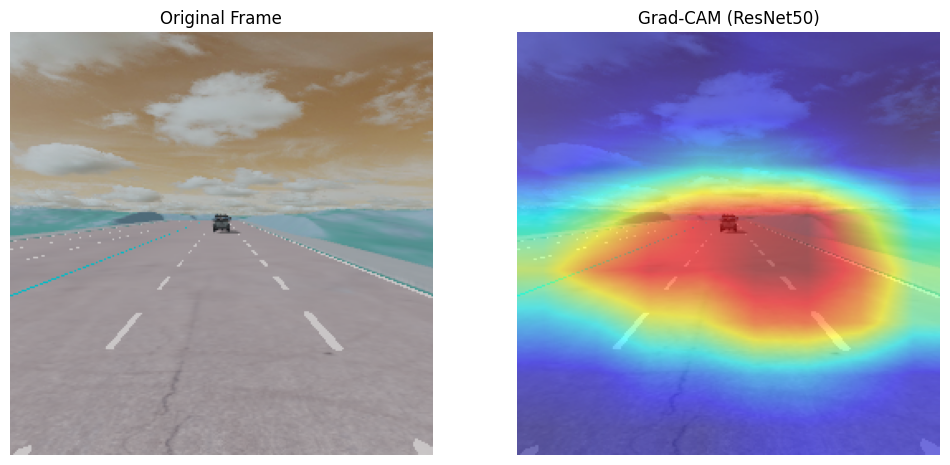

In [ ]:
from torchvision.models import resnet50
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Load Model
model = resnet50(pretrained=True)
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Pick a frame
idx = 25 # Middle of episode
if idx < len(frames):
    img_rgb = frames[idx]
    
    # Preprocess
    img_float = img_rgb.astype(np.float32) / 255.0
    input_tensor = transforms.ToTensor()(img_rgb).unsqueeze(0)
    
    # Generate CAM
    targets = None 
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]
    
    # Overlay
    visualization = show_cam_on_image(img_float, grayscale_cam, use_rgb=True)
    
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img_rgb)
    ax[0].set_title("Original Frame")
    ax[0].axis('off')
    
    ax[1].imshow(visualization)
    ax[1].set_title("Grad-CAM (ResNet50)")
    ax[1].axis('off')
    plt.show()
else:
    print("Not enough frames captured.")

## 4. SHAP Explanation (State Features)
Explaining the actual agent's decisions based on Lidar and Kinematics.

states_tensor shape: torch.Size([50, 19])
Explaining timestep: 25
num_features: 19
ego_dim: 5 lidar_dim: 10 other_dim: 4


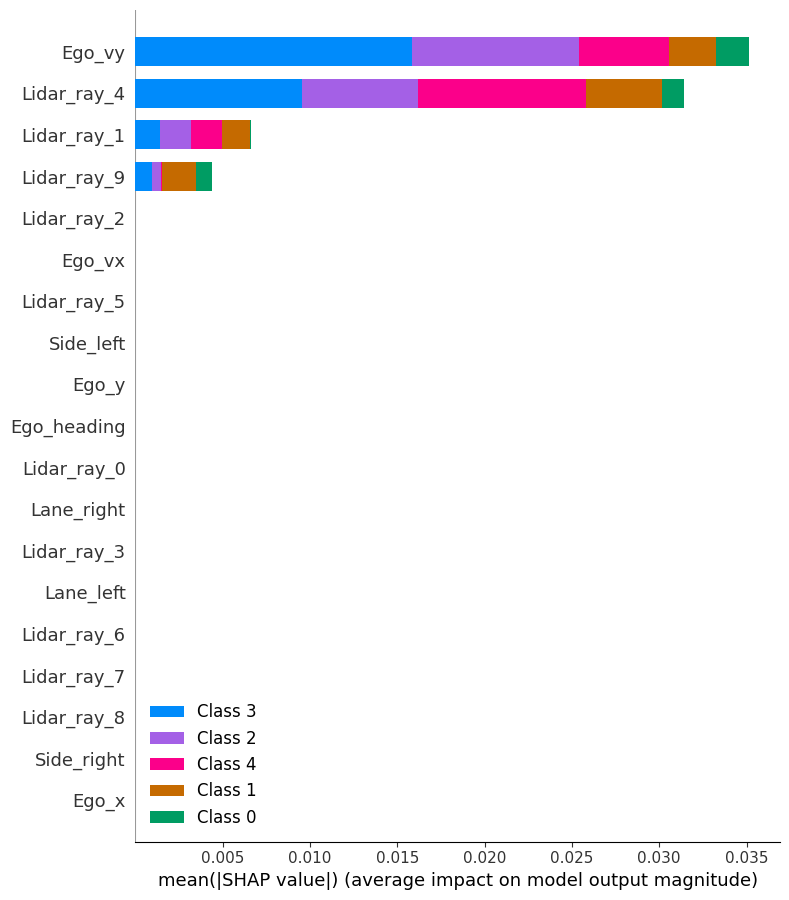

In [5]:
# 4.1 Prepare data
states_tensor = torch.as_tensor(np.stack(states), dtype=torch.float32).to(agent.device)

# Background for SHAP
background = states_tensor[:10]  # first few states as background

# Pick same index as the Grad-CAM frame (or clamp if episode is shorter)
idx = min(25, states_tensor.shape[0] - 1)
to_explain = states_tensor[idx:idx+1]

print("states_tensor shape:", states_tensor.shape)
print("Explaining timestep:", idx)

# 4.2 Build meaningful feature names
num_features = states_tensor.shape[1]

# --- Heuristic partitioning ---
# 1) Ego state dims (position / velocity / heading, etc.)
ego_dim = 5

# 2) Guess lidar dimension.
#    Once you introspect vehicle.lidar.num_lasers you can set it explicitly.
remaining = num_features - ego_dim
other_dim = 4  # e.g., side + lane detectors
lidar_dim = max(0, remaining - other_dim)

# Safety check
if ego_dim + lidar_dim > num_features:
    lidar_dim = max(0, num_features - ego_dim)

print("num_features:", num_features)
print("ego_dim:", ego_dim, "lidar_dim:", lidar_dim, "other_dim:", num_features - ego_dim - lidar_dim)

feature_names = []

# Ego state names
ego_names = ["Ego_x", "Ego_y", "Ego_vx", "Ego_vy", "Ego_heading"]
for i in range(ego_dim):
    if i < len(ego_names):
        feature_names.append(ego_names[i])
    else:
        feature_names.append(f"Ego_feat_{i}")

# Lidar rays
for i in range(lidar_dim):
    feature_names.append(f"Lidar_ray_{i}")

# Remaining features: side + lane detectors (approx)
while len(feature_names) < num_features:
    idx_other = len(feature_names) - ego_dim - lidar_dim
    if idx_other == 0:
        feature_names.append("Side_left")
    elif idx_other == 1:
        feature_names.append("Side_right")
    elif idx_other == 2:
        feature_names.append("Lane_left")
    elif idx_other == 3:
        feature_names.append("Lane_right")
    else:
        feature_names.append(f"Other_feat_{idx_other}")

# 4.3 SHAP
explainer = shap.DeepExplainer(agent.q_net, background)
shap_values = explainer.shap_values(to_explain)

# 4.4 Plot SHAP summary (bar)
shap.summary_plot(
    shap_values,
    to_explain.cpu().numpy(),
    feature_names=feature_names,
    plot_type="bar",
)

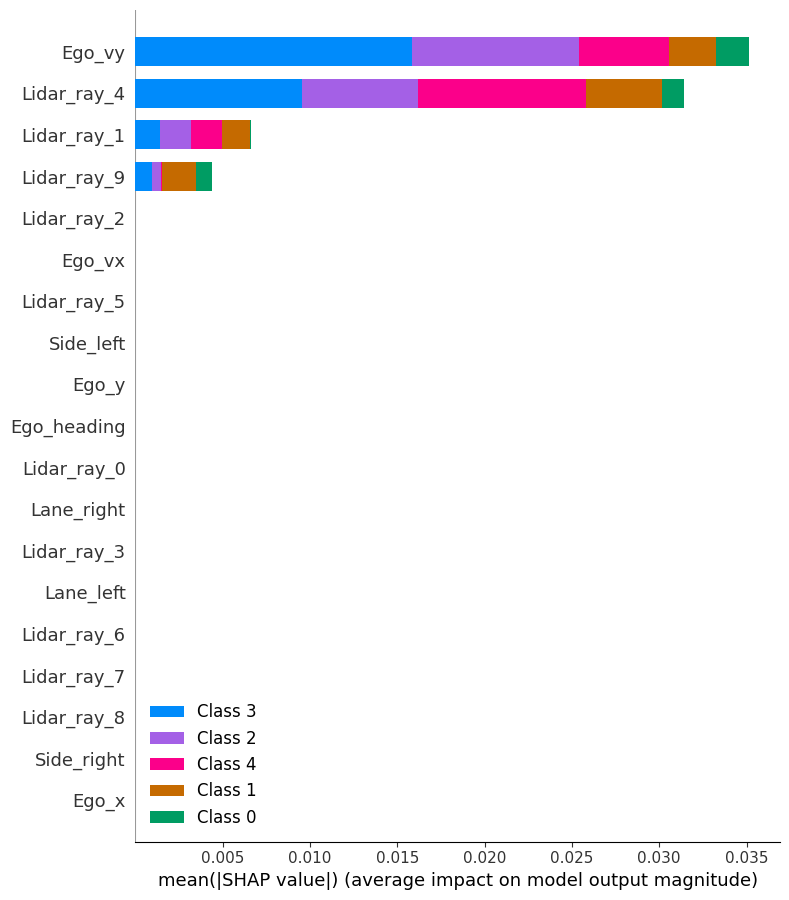

In [6]:
# SHAP
explainer = shap.DeepExplainer(agent.q_net, background)
shap_values = explainer.shap_values(to_explain)

# Plot
shap.summary_plot(
    shap_values,
    to_explain.cpu().numpy(),
    feature_names=feature_names,
    plot_type="bar",
)


In [9]:
# # Prepare data
# states_tensor = torch.as_tensor(np.stack(states), dtype=torch.float32).to(agent.device)
# background = states_tensor[:10] # Use first few states as background
# to_explain = states_tensor[25:26] # Explain the same step as the image

# # SHAP
# explainer = shap.DeepExplainer(agent.q_net, background)
# shap_values = explainer.shap_values(to_explain)

# # Feature names (approximate)
# feature_names = [f"Feat {i}" for i in range(states_tensor.shape[1])]
# # Lidar rays are usually the first N features, then ego state

# # Plot
# shap.summary_plot(shap_values, to_explain.cpu().numpy(), feature_names=feature_names, plot_type="bar")